### **1. Importar librerías y cargar todos los CSV generados**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chi2, skew, kurtosis, pointbiserialr
from IPython.display import display

### **1.b. Carga de csv y configuración inicial**

In [ ]:
# Configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Cargar las tres submuestras (cada una con EDAD, P8_4_2, SEXO) en un diccionario
muestras = {}
for i in range(1, 4):
    # leer cada archivo
    archivo = f"submuestra{i}.csv"
    df = pd.read_csv(archivo)

    # Guardaar la tabla dentro del contenedor usando el nombre de la submuestra como etiqueta
    muestras[f"submuestra{i}"] = df

    # imprimir guardado existoso
    print(f"{archivo}: {len(df)} registros")

# Dataframe combinado con identificador de submuestra
df_total = pd.concat(
    [df.assign(subconjunto=f"Submuestra {i}") for i, (_, df) in enumerate(muestras.items(), start=1)],
    ignore_index=True
)
print(f"\nMuestra combinada: {len(df_total)} registros") # Muetras totales

# Cargar los datasets por sexo e imprimir distribucion
df_hombres = pd.read_csv("sub_hombres.csv")
df_mujeres = pd.read_csv("sub_mujeres.csv")
print(f"Hombres: {len(df_hombres)} | Mujeres: {len(df_mujeres)}")

submuestra1.csv: 100 registros
submuestra2.csv: 100 registros
submuestra3.csv: 100 registros

Muestra combinada: 300 registros
Hombres: 131 | Mujeres: 169


### **2. Crear variable categórica 'edad_grupo'**

In [ ]:
# Agrupar la edad en intervalos definidos con sus etiquetas
bins = [0, 18, 30, 40, 50, 60, 110]
labels = ['<18', '18-29', '30-39', '40-49', '50-59', '60+']

# Aplicar a cada submuestra
for key in muestras:
    muestras[key]['edad_grupo'] = pd.cut(muestras[key]['EDAD'], bins=bins, labels=labels, right=False)

# Aplicar al dataframe combinado
df_total['edad_grupo'] = pd.cut(df_total['EDAD'], bins=bins, labels=labels, right=False)

# Aplicar a hombres y mujeres (para usarlos luego)
df_hombres['edad_grupo'] = pd.cut(df_hombres['EDAD'], bins=bins, labels=labels, right=False)
df_mujeres['edad_grupo'] = pd.cut(df_mujeres['EDAD'], bins=bins, labels=labels, right=False)

# Imprimir datos de la muestra 1
print("Muestra 1:")
print(muestras["submuestra1"][['EDAD', 'edad_grupo', 'P8_4_2']].head())

Muestra 1:
   EDAD edad_grupo  P8_4_2
0    69        60+     1.0
1    61        60+     1.0
2    45      40-49     1.0
3    70        60+     1.0
4    18      18-29     1.0


### **3. Histogramas comparativos de EDAD por submuestra**

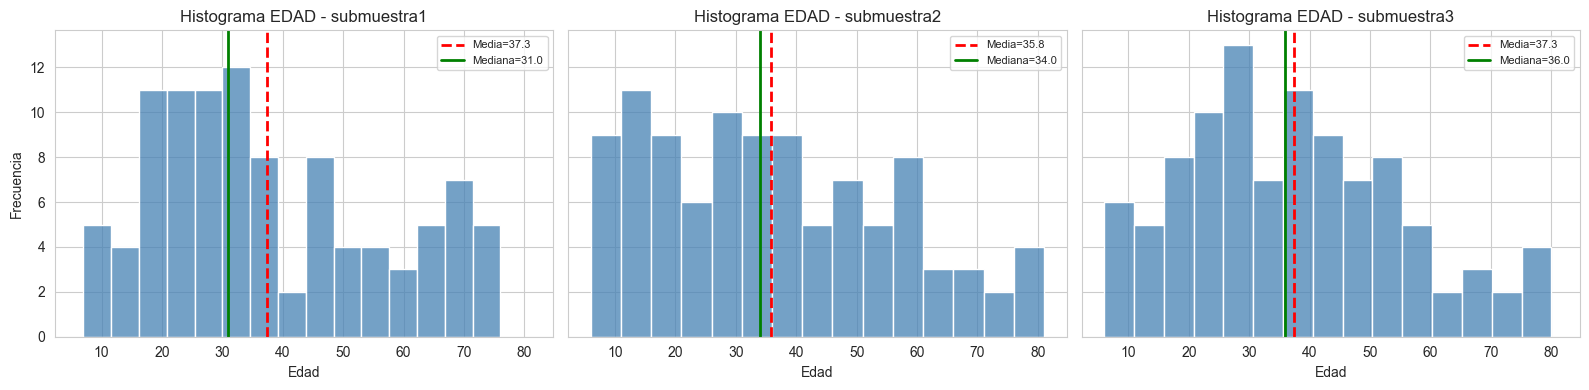

In [ ]:
# Definir una iamgen que puede albergar 3 instancias de graficos
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)

# Imprimir cada grafrica con la configuracion interior
for ax, (nombre, df) in zip(axes, muestras.items()):
    sns.histplot(df['EDAD'], bins=15, kde=False, color='steelblue', ax=ax)
    media = df['EDAD'].mean() # mostrar la media 
    mediana = df['EDAD'].median() # jmostrar la mediana
    ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media={media:.1f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana={mediana:.1f}')
    ax.set_title(f"Histograma EDAD - {nombre}")
    ax.set_xlabel("Edad")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### **4. Estadística Descriptiva de EDAD**

In [ ]:
# Funcion que devuelve un arreglo con los descriptores
def resumen_estadistico(serie):
    return pd.Series({
        'Media': serie.mean(),
        'Mediana': serie.median(),
        'Moda': serie.mode().iloc[0] if not serie.mode().empty else np.nan,
        'Varianza': serie.var(),
        'Desviación estándar': serie.std(),
        'Curtosis': kurtosis(serie, bias=False),
        'Asimetría': skew(serie, bias=False),
        'Q1 (25%)': serie.quantile(0.25),
        'Q2 (50%)': serie.quantile(0.50),
        'Q3 (75%)': serie.quantile(0.75),
        'IQR': serie.quantile(0.75) - serie.quantile(0.25),
        'Rango': serie.max() - serie.min()
    })

# Iterar cada fila
resumen_por_muestra = pd.DataFrame({
    nombre: resumen_estadistico(df['EDAD'])
    for nombre, df in muestras.items()
})
resumen_por_muestra['Muestra combinada'] = resumen_estadistico(df_total['EDAD'])

# Mostrar en formato de Tabla
display(resumen_por_muestra.style.format("{:.2f}").set_caption("Estadísticas descriptivas de EDAD"))

,submuestra1,submuestra2,submuestra3,Muestra combinada
Media,37.34,35.79,37.34,36.82
Mediana,31.00,34.00,36.00,33.50
Moda,26.00,28.00,29.00,28.00
Varianza,359.74,392.71,322.61,356.49
Desviación estándar,18.97,19.82,17.96,18.88
Curtosis,-0.91,-0.82,-0.35,-0.72
Asimetría,0.49,0.40,0.48,0.44
Q1 (25%),23.00,18.00,24.00,23.00
Q2 (50%),31.00,34.00,36.00,33.50
Q3 (75%),51.25,50.50,49.25,50.25


### **5. Boxplots de EDAD por submuestra y por tipo de celular**

C:\Users\Dell\AppData\Local\Temp\ipykernel_23988\320447062.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_total, x='subconjunto', y='EDAD', palette='Set2', ax=axes[0])
C:\Users\Dell\AppData\Local\Temp\ipykernel_23988\320447062.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_total, x='P8_4_2', y='EDAD', palette='Set2', ax=axes[1])
C:\Users\Dell\AppData\Local\Temp\ipykernel_23988\320447062.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Smartphone (1)', 'Básico (2)'])


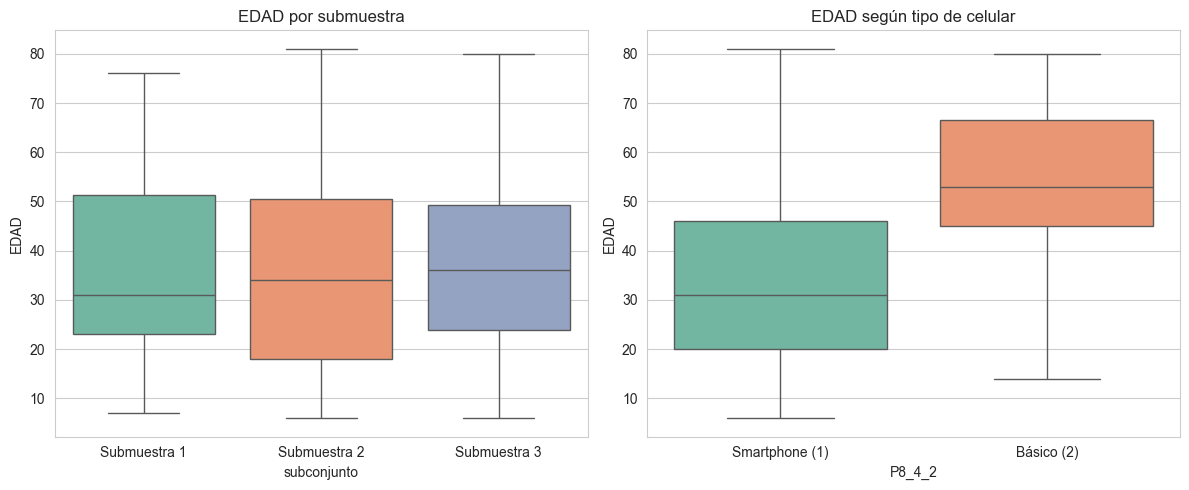

In [ ]:
# Configuracion de una imagen que albergara 2 graficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot de Edad dada cada sumbuestra
sns.boxplot(data=df_total, x='subconjunto', y='EDAD', palette='Set2', ax=axes[0])
axes[0].set_title('EDAD por submuestra')

# Boxplot de Edad dado el tipo de celular
sns.boxplot(data=df_total, x='P8_4_2', y='EDAD', palette='Set2', ax=axes[1])
axes[1].set_title('EDAD según tipo de celular')
axes[1].set_xticklabels(['Smartphone (1)', 'Básico (2)'])

# mostrar grafico limpio
plt.tight_layout()
plt.show()

### **6. Countplot de P8_4_2 por submuestra**

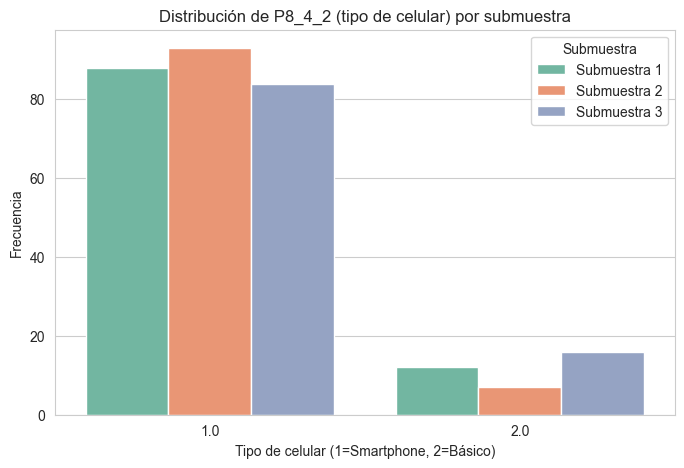

In [ ]:
# Mostrar conteo de tipo de celular por submuestra
plt.figure(figsize=(8, 5))
sns.countplot(data=df_total, x='P8_4_2', hue='subconjunto', palette='Set2') # Grafico dado la submuestra

# Leyenda y mostrar
plt.title('Distribución de P8_4_2 (tipo de celular) por submuestra')
plt.xlabel('Tipo de celular (1=Smartphone, 2=Básico)')
plt.ylabel('Frecuencia')
plt.legend(title='Submuestra')
plt.show()

### **7. Moda de P8_4_2 por submuestra y combinada**

In [ ]:
# Guardar cada moda de submuestra y de todas
modas = []
for nombre, df in muestras.items():
    # moda de tipo de celular
    moda_series = df['P8_4_2'].mode() 

    # obtener la primer moda y frecuencia de la misma
    moda_val = moda_series.iloc[0] if len(moda_series) > 0 else np.nan
    freq = df['P8_4_2'].value_counts().iloc[0]

    # Guardar el nombre de la submuestra, el tipo de celular más común y cuántas veces apareció dentro de la lista.
    modas.append({'Submuestra': nombre, 'Moda': moda_val, 'Frecuencia': freq})

# Obtener lo mismo que el anterior codigo solo que para las muestras combinadas
moda_comb = df_total['P8_4_2'].mode().iloc[0]
freq_comb = df_total['P8_4_2'].value_counts().iloc[0]
modas.append({'Submuestra': 'Combinada', 'Moda': moda_comb, 'Frecuencia': freq_comb})

# mostrar en diseño de tabla
tabla_modas = pd.DataFrame(modas)
display(tabla_modas.style.set_caption("Moda de P8_4_2 (1=Smartphone, 2=Básico)").background_gradient(cmap='Blues', subset=['Frecuencia']))

,Submuestra,Moda,Frecuencia
0,submuestra1,1.000000,88
1,submuestra2,1.000000,93
2,submuestra3,1.000000,84
3,Combinada,1.000000,265


### **8. Tablas de contingencia edad_grupo vs P8_4_2 para cada submuestra**

In [17]:
# obtener la tabla de contigencia entre edades con funcion de pandas
for nombre, df in muestras.items():
    print(f"\n--- {nombre} ---")
    tabla = pd.crosstab(df['edad_grupo'], df['P8_4_2'], margins=True, margins_name='Total')
    display(tabla)

# Obtener la tabla de contingencia para toda la muestra
print("\n--- Muestra combinada ---")
tabla_total = pd.crosstab(df_total['edad_grupo'], df_total['P8_4_2'], margins=True, margins_name='Total')
display(tabla_total)


--- submuestra1 ---


P8_4_2,1.0,2.0,Total
edad_grupo,,,
<18,13,0,13
18-29,28,1,29
30-39,20,0,20
40-49,8,3,11
50-59,6,2,8
60+,13,6,19
Total,88,12,100



--- submuestra2 ---


P8_4_2,1.0,2.0,Total
edad_grupo,,,
<18,22,1,23
18-29,20,2,22
30-39,17,0,17
40-49,10,1,11
50-59,11,1,12
60+,13,2,15
Total,93,7,100



--- submuestra3 ---


P8_4_2,1.0,2.0,Total
edad_grupo,,,
<18,13,0,13
18-29,26,1,27
30-39,15,2,17
40-49,16,2,18
50-59,8,5,13
60+,6,6,12
Total,84,16,100



--- Muestra combinada ---


P8_4_2,1.0,2.0,Total
edad_grupo,,,
<18,48,1,49
18-29,74,4,78
30-39,52,2,54
40-49,34,6,40
50-59,25,8,33
60+,32,14,46
Total,265,35,300


### **9. Frecuencias esperadas y chi‑cuadrado para cada submuestra**

In [18]:
# obtener frecuencias esperadas, chi cuadrada y p value para cada submuestra
for nombre, df in muestras.items():
    # tablas de contigencia
    tabla = pd.crosstab(df['edad_grupo'], df['P8_4_2']) 

    # datos que entrega la prueba chi con tablas de contigencia, libreria scipy.stats
    chi2_val, p_val, dof, esperados = chi2_contingency(tabla) 

    # Imprimir informacion
    print(f"\n--- {nombre} | Frecuencias esperadas ---")
    df_esper = pd.DataFrame(esperados, index=tabla.index, columns=tabla.columns)
    display(df_esper.style.format("{:.2f}"))
    print(f"χ² = {chi2_val:.3f}, g.l. = {dof}, p = {p_val:.6f}")

# Obtener el calor de la chi para toda la muestra
# tabla de contigencia
tabla_total = pd.crosstab(df_total['edad_grupo'], df_total['P8_4_2'])

# datos que entrega la prueba chi con tablas de contigencia, libreria scipy.stats
chi2_total, p_total, dof_total, esperados_total = chi2_contingency(tabla_total)

# Imprimir informacion
print("\n--- Muestra combinada | Frecuencias esperadas ---")
df_esper_total = pd.DataFrame(esperados_total, index=tabla_total.index, columns=tabla_total.columns)
display(df_esper_total.style.format("{:.2f}"))
print(f"χ² = {chi2_total:.3f}, g.l. = {dof_total}, p = {p_total:.6f}")


--- submuestra1 | Frecuencias esperadas ---


P8_4_2,1.000000,2.000000
edad_grupo,,
<18,11.44,1.56
18-29,25.52,3.48
30-39,17.60,2.40
40-49,9.68,1.32
50-59,7.04,0.96
60+,16.72,2.28


χ² = 17.116, g.l. = 5, p = 0.004286

--- submuestra2 | Frecuencias esperadas ---


P8_4_2,1.000000,2.000000
edad_grupo,,
<18,21.39,1.61
18-29,20.46,1.54
30-39,15.81,1.19
40-49,10.23,0.77
50-59,11.16,0.84
60+,13.95,1.05


χ² = 2.707, g.l. = 5, p = 0.745095

--- submuestra3 | Frecuencias esperadas ---


P8_4_2,1.000000,2.000000
edad_grupo,,
<18,10.92,2.08
18-29,22.68,4.32
30-39,14.28,2.72
40-49,15.12,2.88
50-59,10.92,2.08
60+,10.08,1.92


χ² = 21.262, g.l. = 5, p = 0.000723

--- Muestra combinada | Frecuencias esperadas ---


P8_4_2,1.000000,2.000000
edad_grupo,,
<18,43.28,5.72
18-29,68.90,9.10
30-39,47.70,6.30
40-49,35.33,4.67
50-59,29.15,3.85
60+,40.63,5.37


χ² = 32.182, g.l. = 5, p = 0.000005


### **10. Resumen de chi‑cuadrado para todas las muestras (α=0.005)**

Usamos un nivel de significancia de 0.005 supuesto

In [16]:
alpha = 0.005
resultados_chi = []

for nombre, df in list(muestras.items()) + [('Combinada', df_total)]:
    tabla = pd.crosstab(df['edad_grupo'], df['P8_4_2'])
    chi2_calc, p_val, dof, _ = chi2_contingency(tabla)
    chi2_teo = chi2.ppf(1 - alpha, dof)
    resultados_chi.append({
        'Muestra': nombre,
        'χ² calculado': chi2_calc,
        'g.l.': dof,
        'χ² teórico (α=0.005)': chi2_teo,
        'p-valor': p_val,
        'Significativa (α=0.005)': 'Sí' if p_val < alpha else 'No'
    })

resumen_chi = pd.DataFrame(resultados_chi)
display(resumen_chi.style.format({
    'χ² calculado': '{:.3f}',
    'χ² teórico (α=0.005)': '{:.3f}',
    'p-valor': '{:.6f}'
}).set_caption("Prueba de independencia χ² (Edad agrupada vs Tipo de celular)"))

,Muestra,χ² calculado,g.l.,χ² teórico (α=0.005),p-valor,Significativa (α=0.005)
0,submuestra1,17.116,5,16.750,0.004286,Sí
1,submuestra2,2.707,5,16.750,0.745095,No
2,submuestra3,21.262,5,16.750,0.000723,Sí
3,Combinada,32.182,5,16.750,0.000005,Sí


### **11. V de Cramér**

In [19]:
# Definicion del calculo de v de cramer
def cramer_v(tabla):
    # obtener valor chi
    chi2, _, _, _ = chi2_contingency(tabla)

    # sumar todos los elementos de la tabla
    n = tabla.sum().sum()

    # formula de la v de cramer usando filas y columnas de la tabla
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * min(k-1, r-1)))

# calcular cada v de cramer
print("V de Cramér (Edad vs Tipo de celular):")
for nombre, df in list(muestras.items()) + [('Combinada', df_total)]:
    # tabla de contigencia
    tabla = pd.crosstab(df['edad_grupo'], df['P8_4_2'])
    # v de cramer para cada submuestra y muestra combinada
    v = cramer_v(tabla)
    print(f"  {nombre}: {v:.3f}")

V de Cramér (Edad vs Tipo de celular):
  submuestra1: 0.414
  submuestra2: 0.165
  submuestra3: 0.461
  Combinada: 0.328


### **12. Proporción de tipo de celular por grupo de edad (muestra combinada)**

In [ ]:
# Obtener el porcentaje de tipo de celular por grupo de eddad
prop_cel = df_total.groupby('edad_grupo')['P8_4_2'].value_counts(normalize=True).unstack()
print("Proporción de tipo de celular por grupo de edad:")
# imprimir con formato de tabla
display(prop_cel.style.format('{:.2%}').background_gradient(cmap='Blues'))

# obtener moda por gurpo de edad
moda_edad = df_total.groupby('edad_grupo')['P8_4_2'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
print("\nModa de P8_4_2 por grupo de edad:")
# imprimir con formato de tabla
display(moda_edad.to_frame('Moda').style.background_gradient(cmap='Blues'))

Proporción de tipo de celular por grupo de edad:


C:\Users\Dell\AppData\Local\Temp\ipykernel_23988\2678437241.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_cel = df_total.groupby('edad_grupo')['P8_4_2'].value_counts(normalize=True).unstack()


P8_4_2,1.000000,2.000000
edad_grupo,,
<18,97.96%,2.04%
18-29,94.87%,5.13%
30-39,96.30%,3.70%
40-49,85.00%,15.00%
50-59,75.76%,24.24%
60+,69.57%,30.43%



Moda de P8_4_2 por grupo de edad:


C:\Users\Dell\AppData\Local\Temp\ipykernel_23988\2678437241.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  moda_edad = df_total.groupby('edad_grupo')['P8_4_2'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)


,Moda
edad_grupo,
<18,1.000000
18-29,1.000000
30-39,1.000000
40-49,1.000000
50-59,1.000000
60+,1.000000


### **13. Gráfico de líneas de tendencia por grupo de edad**

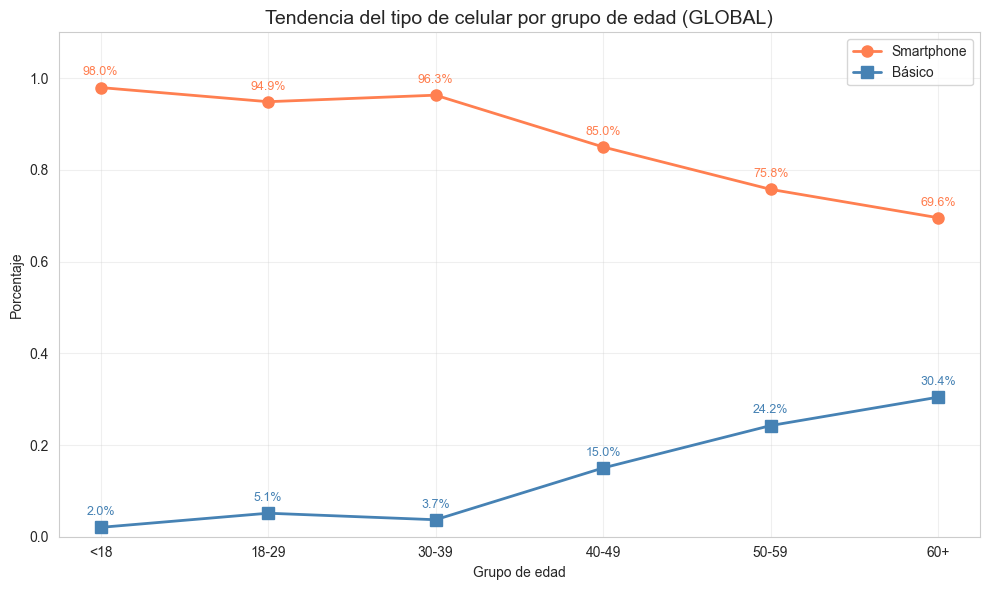

In [26]:
# Creamos una copia con nombres más claros y ordenamos por grupo de edad
prop_grafico = prop_cel.copy()
prop_grafico.columns = ['Smartphone', 'Básico']  # renombrar columnas
# Ordenar grupos de edad correctamente
prop_grafico = prop_grafico.reset_index()

# Configurar el gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Línea para Smartphone
ax.plot(prop_grafico['edad_grupo'], prop_grafico['Smartphone'], 
        marker='o', color='coral', linewidth=2, markersize=8, label='Smartphone')

# Línea para Básico
ax.plot(prop_grafico['edad_grupo'], prop_grafico['Básico'], 
        marker='s', color='steelblue', linewidth=2, markersize=8, label='Básico')

# Añadir etiquetas con los porcentajes
for i, fila in prop_grafico.iterrows():
    ax.text(i, fila['Smartphone'] + 0.02, f"{fila['Smartphone']:.1%}", 
            ha='center', va='bottom', fontsize=9, color='coral')
    ax.text(i, fila['Básico'] + 0.02, f"{fila['Básico']:.1%}", 
            ha='center', va='bottom', fontsize=9, color='steelblue')

# Formato del gráfico
ax.set_title('Tendencia del tipo de celular por grupo de edad (GLOBAL)', fontsize=14)
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Porcentaje')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **14. Distribución de tipo de celular por sexo (tabla y gráfico)**

Distribución de P8_4_2 en Hombres:
P8_4_2
1.0    88.5%
2.0    11.5%
Name: proportion, dtype: object

Distribución de P8_4_2 en Mujeres:
P8_4_2
1.0    88.2%
2.0    11.8%
Name: proportion, dtype: object


P8_4_2,Smartphone,Básico
Hombre,88.5%,11.5%
Mujer,88.2%,11.8%


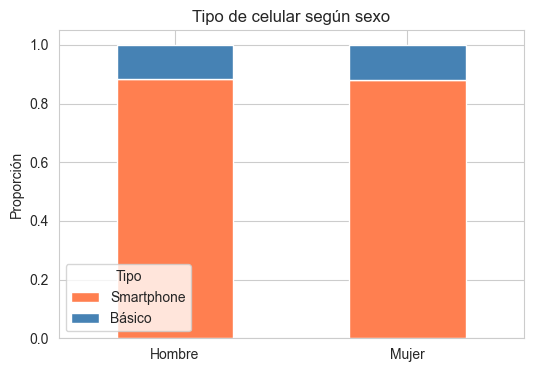

In [28]:
# Obtener la distribucion de tipo de celcular por sexo
print("Distribución de P8_4_2 en Hombres:")
print(df_hombres['P8_4_2'].value_counts(normalize=True).map("{:.1%}".format))
print("\nDistribución de P8_4_2 en Mujeres:")
print(df_mujeres['P8_4_2'].value_counts(normalize=True).map("{:.1%}".format))

# Tabla resumen
prop_sexo = pd.DataFrame({
    'Hombre': df_hombres['P8_4_2'].value_counts(normalize=True),
    'Mujer': df_mujeres['P8_4_2'].value_counts(normalize=True)
}).T
prop_sexo = prop_sexo.rename(columns={1:'Smartphone', 2:'Básico'}) # renombar columnas
display(prop_sexo.style.format("{:.1%}").background_gradient(cmap='Blues'))

# Gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(6,4))
prop_sexo.plot(kind='bar', stacked=True, ax=ax, color=['coral','steelblue'])
ax.set_title('Tipo de celular según sexo')
ax.set_ylabel('Proporción')
ax.legend(title='Tipo')
plt.xticks(rotation=0)
plt.show()

### **15. Boxplot de EDAD por sexo y descriptivos**

C:\Users\Dell\AppData\Local\Temp\ipykernel_23988\146781369.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sexo, x='Sexo', y='EDAD', palette='Set2')


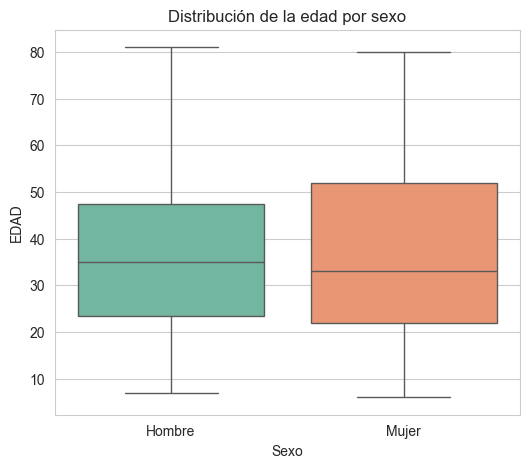

Resumen de EDAD por sexo:
Hombres:


,count,mean,std,min,25%,50%,75%,max
EDAD,131.0,36.5,18.5,7.0,23.5,35.0,47.5,81.0


Mujeres:


,count,mean,std,min,25%,50%,75%,max
EDAD,169.0,37.1,19.3,6.0,22.0,33.0,52.0,80.0


In [29]:
# Preparar datos para boxplot
df_sexo = pd.concat([
    df_hombres.assign(Sexo='Hombre'),
    df_mujeres.assign(Sexo='Mujer')
])

# Bloxplot divido por sexo para la edad
plt.figure(figsize=(6,5))
sns.boxplot(data=df_sexo, x='Sexo', y='EDAD', palette='Set2')
plt.title('Distribución de la edad por sexo')
plt.show()

# Resumen estadistico de de pandasr por sexo, .describe
print("Resumen de EDAD por sexo:")
print("Hombres:")
display(df_hombres['EDAD'].describe().to_frame().T.style.format("{:.1f}"))
print("Mujeres:")
display(df_mujeres['EDAD'].describe().to_frame().T.style.format("{:.1f}"))

### **16. Tabla de contingencia Sexo vs Tipo de celular**

In [30]:
# Tabla de contigencia comparando el sexo y el tipo de celular
tabla_sexo = pd.crosstab(df_total['SEXO'], df_total['P8_4_2'])
# valor que entrega la prueba chi por tablas de contigencia
chi2_sexo, p_sexo, dof_sexo, _ = chi2_contingency(tabla_sexo)
# v de cramer
v_sexo = cramer_v(tabla_sexo)

# imprimir datos
print("Tabla de contingencia Sexo vs Tipo de celular:")
display(tabla_sexo.rename(index={1:'Hombre',2:'Mujer'}, columns={1:'Smartphone',2:'Básico'}))
print(f"χ² = {chi2_sexo:.3f}, g.l. = {dof_sexo}, p = {p_sexo:.6f}, V de Cramér = {v_sexo:.3f}")

Tabla de contingencia Sexo vs Tipo de celular:


P8_4_2,Smartphone,Básico
SEXO,,
Hombre,116,15
Mujer,149,20


χ² = 0.000, g.l. = 1, p = 1.000000, V de Cramér = 0.000


### **17. Correlación punto‑biserial EDAD vs Smartphone**

In [ ]:
# Crea una columna nueva donde 1 significa "Tiene Smartphone" y 0 significa "No tiene".
df_total['cel_smart'] = df_total['P8_4_2'].map({1:1, 2:0})

# Hace la prueba estadística cruzando la EDAD con la nueva columna de Smartphone.
r_pb, p_pb = pointbiserialr(df_total['EDAD'], df_total['cel_smart'])

# Imprimir resultado
print(f"Correlación punto‑biserial EDAD vs Smartphone: r = {r_pb:.3f}, p = {p_pb:.6f}")

Correlación punto‑biserial EDAD vs Smartphone: r = -0.312, p = 0.000000
